In [1]:
# Notebook inspiré de https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html
%matplotlib inline

Compression avec un Sequence to Sequence Network et Attention
===============================================================================

L'objectif de ce notebook est d'explorer les performances d'un modèle de traduction pour compresser des séquences qui nous intéressent

Dans ce projet nous allons entrainer un réseau de neurone pour traduire des séquences de tokens en leur version compressées

Exemples de ce que l'on souhaite obtenir (les [] marquent une répétition et les * des tokens optionnels) :
``` {.sh}
[KEY: > input, = target]

> A B B B B B B C
= A [ B ] C

> D D D D D D E D D
= [E*DE*]

> G E F E F E F E T F E F E F
= G[ET*F]
```

**Requirements**


In [2]:
from __future__ import unicode_literals, print_function, division
from io import open, BytesIO
from IPython.display import Image, display
import unicodedata
import re
from random import choice
import os
import io

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if str(device) == "cuda":
    print("GPU detected.")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")
else:
    print("No GPU detected. Using CPU.")

GPU detected.
GPU Memory: 42.14 GB
Free: 41.61 GB


Chargement du dataset
==================
Les données d'apprentissages sont chargées à partir du fichier `long-comp_forlearning.txt`, l'évaluation du modèle est calculé à partir du fichier `long-comp_fortesting.txt`. Voir le notebook `1-MAP_IA_BuildDataSet.ipynb` pour la génération de ces fichiers.

Nous aurons besoin d'un index unique par token à utiliser comme entrées et cibles des réseaux ultérieurement. Pour garder une trace de tout cela, nous utiliserons une classe d'aide appelée `Lang` qui contient des dictionnaires token → index (`token2index`) et index → token (`index2token`).

In [3]:
SOS_token = 0
EOS_token = 1

class Lang:
    def __init__(self, name):
        self.name = name
        self.token2index = {}
        self.index2token = {0: "SOS", 1: "EOS"}
        self.n_words = 2  # Count SOS and EOS

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.token2index:
            self.token2index[word] = self.n_words
            self.index2token[self.n_words] = word
            self.n_words += 1

On normalise une séquence de token en séparant chaque token par un espace


In [4]:
def normalizeSequence(s):
    s = s.replace(" ", ""); # suppression de tous les espaces
    return " ".join(s) # ajout d'un seul espace entre chaque caractère

Pour lire le fichier de données, nous allons diviser le fichier en lignes, puis diviser les lignes en paires. Le dataset est de la forme `séquence non compressée` → `séquence compressée`.

In [5]:
def readLangs(lang1, lang2):
    print("Reading lines...")

    # Read the file and split into lines
    lines = open('%s-%s_forlearning.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')

    # Split every line into pairs and normalize
    pairs = [[normalizeSequence(s) for s in l.split('\t')] for l in lines]

    # Make Lang instances
    input_lang = Lang(lang1)
    output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

Le process complet de préparation des données est don cle suivant:

-   Lire le fichier texte et le décomposer en ligne, décomposer chaque ligne en paires
-   Normaliser les textes et compter la séquence la plus longue
-   Créer la liste des tokens à partir des paires de séquences


In [6]:
MAX_LENGTH = -1

def prepareData(lang1, lang2):
    global MAX_LENGTH
    input_lang, output_lang, pairs = readLangs(lang1, lang2)
    print("Read %s sentence pairs" % len(pairs))
    print("Counting tokens...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
        if len(pair[0]) > MAX_LENGTH:
            MAX_LENGTH = len(pair[0])
        if len(pair[1]) > MAX_LENGTH:
            MAX_LENGTH = len(pair[1])
            
    print("Counted tokens:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    print("Max token count: "+str(int((MAX_LENGTH+1)/2))) # on ne compte pas les espaces
    
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('long', 'comp')
print(choice(pairs))

Reading lines...
Read 15318 sentence pairs
Counting tokens...
Counted tokens:
long 28
comp 31
Max token count: 52
['N B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O B O M', 'N [ B O ] M']


The Seq2Seq Model
=================

A Recurrent Neural Network, or RNN, is a network that operates on a
sequence and uses its own output as input for subsequent steps.

A [Sequence to Sequence network](https://arxiv.org/abs/1409.3215), or
seq2seq network, or [Encoder Decoder
network](https://arxiv.org/pdf/1406.1078v3.pdf), is a model consisting
of two RNNs called the encoder and decoder. The encoder reads an input
sequence and outputs a single vector, and the decoder reads that vector
to produce an output sequence.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/seq2seq.png)

Unlike sequence prediction with a single RNN, where every input
corresponds to an output, the seq2seq model frees us from sequence
length and order, which makes it ideal for translation between two
languages.

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE :</strong></div>
<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">
<p>La question c'est : est-ce que c'est aussi prometteur pour la tache de réduction de séquence que l'on souhaite faire ?</p>
</div>

With a seq2seq model the encoder creates a single vector which, in the
ideal case, encodes the \"meaning\" of the input sequence into a single
vector --- a single point in some N dimensional space of sentences.


The Encoder
===========

The encoder of a seq2seq network is a RNN that outputs some value for
every word from the input sentence. For every input word the encoder
outputs a vector and a hidden state, and uses the hidden state for the
next input word.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/encoder-network.png)


In [7]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

The Decoder
===========

The decoder is another RNN that takes the encoder output vector(s) and
outputs a sequence of words to create the translation.


Simple Decoder
==============

In the simplest seq2seq decoder we use only last output of the encoder.
This last output is sometimes called the *context vector* as it encodes
context from the entire sequence. This context vector is used as the
initial hidden state of the decoder.

At every step of decoding, the decoder is given an input token and
hidden state. The initial input token is the start-of-string `<SOS>`
token, and the first hidden state is the context vector (the encoder\'s
last hidden state).

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/decoder-network.png)


In [8]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

Attention Decoder
=================

If only the context vector is passed between the encoder and decoder,
that single vector carries the burden of encoding the entire sentence.

Attention allows the decoder network to \"focus\" on a different part of
the encoder\'s outputs for every step of the decoder\'s own outputs.
First we calculate a set of *attention weights*. These will be
multiplied by the encoder output vectors to create a weighted
combination. The result (called `attn_applied` in the code) should
contain information about that specific part of the input sequence, and
thus help the decoder choose the right output words.

![](https://i.imgur.com/1152PYf.png)

Calculating the attention weights is done with another feed-forward
layer `attn`, using the decoder\'s input and hidden state as inputs.
Because there are sentences of all sizes in the training data, to
actually create and train this layer we have to choose a maximum
sentence length (input length, for encoder outputs) that it can apply
to. Sentences of the maximum length will use all the attention weights,
while shorter sentences will only use the first few.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/attention-decoder-network.png)

Bahdanau attention, also known as additive attention, is a commonly used
attention mechanism in sequence-to-sequence models, particularly in
neural machine translation tasks. It was introduced by Bahdanau et al.
in their paper titled [Neural Machine Translation by Jointly Learning to
Align and Translate](https://arxiv.org/pdf/1409.0473.pdf). This
attention mechanism employs a learned alignment model to compute
attention scores between the encoder and decoder hidden states. It
utilizes a feed-forward neural network to calculate alignment scores.

However, there are alternative attention mechanisms available, such as
Luong attention, which computes attention scores by taking the dot
product between the decoder hidden state and the encoder hidden states.
It does not involve the non-linear transformation used in Bahdanau
attention.

In this tutorial, we will be using Bahdanau attention. However, it would
be a valuable exercise to explore modifying the attention mechanism to
use Luong attention.


In [9]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input))

        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)

        return output, hidden, attn_weights

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>There are other forms of attention that work around the lengthlimitation by using a relative position approach. Read about "localattention" in <a href="https://arxiv.org/abs/1508.04025">Effective Approaches to Attention-based Neural MachineTranslation</a>.</p>

</div>

Training
========

Preparing Training Data
-----------------------

To train, for each pair we will need an input tensor (indexes of the
words in the input sentence) and target tensor (indexes of the words in
the target sentence). While creating these vectors we will append the
EOS token to both sequences.


In [10]:
def indexesFromSentence(lang, sentence):
    return [lang.token2index[word] for word in sentence.split(' ')]
    
def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepareData('long', 'comp')
    
    n = len(pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    train_data = TensorDataset(torch.LongTensor(input_ids).to(device),
                               torch.LongTensor(target_ids).to(device))

    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
    return input_lang, output_lang, train_dataloader

Training the Model
==================

To train we run the input sentence through the encoder, and keep track
of every output and the latest hidden state. Then the decoder is given
the `<SOS>` token as its first input, and the last hidden state of the
encoder as its first hidden state.

\"Teacher forcing\" is the concept of using the real target outputs as
each next input, instead of using the decoder\'s guess as the next
input. Using teacher forcing causes it to converge faster but [when the
trained network is exploited, it may exhibit
instability](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.378.4095&rep=rep1&type=pdf).

You can observe outputs of teacher-forced networks that read with
coherent grammar but wander far from the correct translation
-intuitively it has learned to represent the output grammar and can
\"pick up\" the meaning once the teacher tells it the first few words,
but it has not properly learned how to create the sentence from the
translation in the first place.

Because of the freedom PyTorch\'s autograd gives us, we can randomly
choose to use teacher forcing or not with a simple if statement. Turn
`teacher_forcing_ratio` up to use more of it.


In [11]:
def train_epoch(epoch_num, dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion):

    total_loss = 0
    pos = 0
    for data in dataloader:
        print ("Training epoch "+str(epoch_num)+": "+str(int(10000*pos/len(dataloader))/100)+"%    ", end='\r')
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()
        pos += 1

    return total_loss / len(dataloader)

This is a helper function to print time elapsed and estimated time
remaining given the current time and progress %.


In [12]:
import time
import math

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

The whole training process looks like this:

-   Start a timer
-   Initialize optimizers and criterion
-   Create set of training pairs
-   Start empty losses array for plotting

Then we call `train` many times and occasionally print the progress (%
of examples, time so far, estimated time) and average loss.


In [13]:
def train(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001,
               print_every=100, plot_every=100):
    encoder.train()
    decoder.train()
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(epoch, train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs),
                                        epoch, epoch / n_epochs * 100, print_loss_avg))

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

Plotting results
================

Plotting is done with matplotlib, using the array of loss values
`plot_losses` saved while training.


In [14]:
import matplotlib.pyplot as plt
plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)
    # Sauvegarder en mémoire et afficher dans Jupyter
    buffer = io.BytesIO()
    plt.savefig(buffer, format='png', dpi=75, bbox_inches='tight')
    buffer.seek(0)
    
    # Afficher dans Jupyter
    display(Image(buffer.getvalue()))
    
    plt.close()
    buffer.close()

Training
=======================

With all these helper functions in place (it looks like extra work, but
it makes it easier to run multiple experiments) we can actually
initialize a network and start training.

Remember that the input sentences were heavily filtered. For this small
dataset we can use relatively small networks of 256 hidden nodes and a
single GRU layer. After about 40 minutes on a MacBook CPU we\'ll get
some reasonable results.

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>If you run this notebook you can train, interrupt the kernel,evaluate, and continue training later. Comment out the lines where theencoder and decoder are initialized and run <code>trainIters</code> again.</p>

</div>



In [15]:
hidden_size = 128
batch_size = 32
epocs = 80
learning_rate=0.001

Get data...
Reading lines...
Read 15318 sentence pairs
Counting tokens...
Counted tokens:
long 28
comp 31
Max token count: 52
Build encoder...
Build decoder...
Training...
1m 19s (- 104m 28s) (1 1%) 0.2160
2m 37s (- 102m 7s) (2 2%) 0.1319
3m 54s (- 100m 12s) (3 3%) 0.0819
5m 11s (- 98m 40s) (4 5%) 0.0536
6m 29s (- 97m 15s) (5 6%) 0.0409
7m 46s (- 95m 51s) (6 7%) 0.0335
9m 3s (- 94m 26s) (7 8%) 0.0288
10m 20s (- 93m 4s) (8 10%) 0.0254
11m 37s (- 91m 42s) (9 11%) 0.0225
12m 56s (- 90m 35s) (10 12%) 0.0200
14m 15s (- 89m 26s) (11 13%) 0.0183
15m 33s (- 88m 10s) (12 15%) 0.0169
16m 51s (- 86m 52s) (13 16%) 0.0156
18m 8s (- 85m 33s) (14 17%) 0.0145
19m 26s (- 84m 16s) (15 18%) 0.0137
20m 44s (- 82m 57s) (16 20%) 0.0129
22m 1s (- 81m 38s) (17 21%) 0.0121
23m 19s (- 80m 19s) (18 22%) 0.0115
24m 37s (- 79m 3s) (19 23%) 0.0108
25m 55s (- 77m 45s) (20 25%) 0.0108
27m 12s (- 76m 27s) (21 26%) 0.0097
28m 30s (- 75m 9s) (22 27%) 0.0091
29m 49s (- 73m 54s) (23 28%) 0.0089
31m 7s (- 72m 36s) (24 30%)

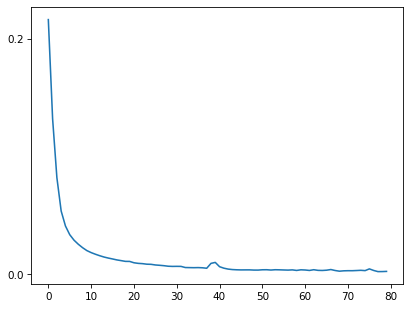

In [16]:
torch.cuda.empty_cache()

print("Get data...")
input_lang, output_lang, train_dataloader = get_dataloader(batch_size)
print("Build encoder...")
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
print("Build decoder...")
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)
print("Training...")
train(train_dataloader, encoder, decoder, epocs, learning_rate=learning_rate, print_every=1, plot_every=1)

Saving models
-------------

In [17]:
torch.save(encoder.state_dict(), "encoderSave.model")
torch.save(decoder.state_dict(), "decoderSave.model")

Loading models
--------------

In [34]:

print("Get data...")
input_lang, output_lang, train_dataloader = get_dataloader(batch_size)
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
encoder.load_state_dict(torch.load("encoderSave.model", weights_only=True))
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)
decoder.load_state_dict(torch.load("decoderSave.model", weights_only=True))


Get data...
Reading lines...
Read 13320 sentence pairs
Counting tokens...
Counted tokens:
long 28
comp 31
Max token count: 50


<All keys matched successfully>

Evaluation
==========

Evaluation is mostly the same as training, but there are no targets so
we simply feed the decoder\'s predictions back to itself for each step.
Every time it predicts a word we add it to the output string, and if it
predicts the EOS token we stop there. We also store the decoder\'s
attention outputs for display later.


In [18]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2token[idx.item()])
    return decoded_words, decoder_attn

We can evaluate random sentences from the training set and print out the
input, target, and output to make some subjective quality judgements:


In [19]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

In [20]:
evaluateRandomly(encoder, decoder)

> A F W F W F W F W A F W F W F W F W F W F W F W F W F W F W F W A F W F W F W F W F W F W F W A F W
= [ A [ F W ] ]
< [ A [ F W ] ] <EOS>

> R J B P J P J P J B P R J P J P J B P J B P J P J P J P
= [ R [ J B * P ] ]
< R [ J B P ] [ J [ P ] ] <EOS>

> C C C C C C C C C C C Q C C Q C C C C C C C C C Q C Q C Q
= [ [ C ] Q ]
< [ C Q * ] <EOS>

> P P P P P P P P P P P P P P P P P P R P P P P P P P P P R P P P P P P P P P P P P R
= [ [ P ] R ]
< [ P [ R P ] ] <EOS>

> O H H L H L H O H L H L H O H
= [ O [ L * H L * ] ]
< [ O [ L * H L * ] ] <EOS>

> Y Y Y Y P W Y Y P W P W Y Y
= [ [ P W ] * Y [ P W ] * ]
< [ P [ W P * Y ] W <EOS>

> W J I Q J I Q J I Q J I Q J I Q J I Q J I Q J I Q H
= W [ J I Q ] H
< W [ J I ] Q <EOS>

> D D D D D D D D D D D D D D D G G G G G G G G G G
= [ D ] [ G ]
< [ D G ] [ G ] <EOS>

> P P P P X P P P P X P P P K X P P X P P P X P X
= [ [ K * P K * ] X ]
< [ X K * P ] <EOS>

> K B P B P B P B P B P B P K B D P B P B P B P B P B P K B P K B P B P
= [ K [ B D * P ] ]

Visualizing Attention
=====================

A useful property of the attention mechanism is its highly interpretable
outputs. Because it is used to weight specific encoder outputs of the
input sequence, we can imagine looking where the network is focused most
at each time step.

You could simply run `plt.matshow(attentions)` to see attention output
displayed as a matrix. For a better viewing experience we will do the
extra work of adding axes and labels:


input = A B A B A B A B A B
output = [ A B ] * ] <EOS>


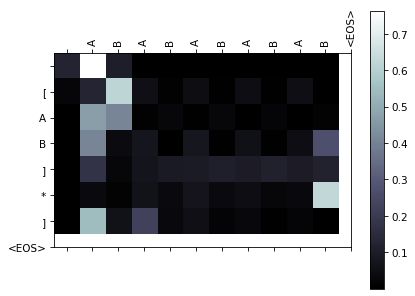

In [21]:
def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.xaxis.set_ticks(list(range(0, len(input_sentence.split(' '))+2)))
    ax.set_xticklabels([''] + input_sentence.split(' ') +
                       ['<EOS>'], rotation=90)
    ax.yaxis.set_ticks(list(range(0, len(output_words)+1)))
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    #plt.show()
    
    # Sauvegarder en mémoire et afficher dans Jupyter
    buffer = io.BytesIO()
    plt.savefig(buffer, format='png', dpi=75, bbox_inches='tight')
    buffer.seek(0)
    
    # Afficher dans Jupyter
    display(Image(buffer.getvalue()))
    
    plt.close()
    buffer.close()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :])

evaluateAndShowAttention('A B A B A B A B A B')


Calcul des données de comparaison avec les autes modèles
=====================================================
On utilise la structure de fichier construite à partir du fichier `long-comp_fortesting.txt` voir le notebook `1-MAP_IA_BuildDataSet.ipynb`

In [23]:
import os
    
def process_and_evaluate():
    exemple_dir = 'example'
    solutions_dir = 'example/solutions'

    #identifier le nombre de scénario
    maxNb = 0
    for example_filename in os.listdir(exemple_dir):
        if example_filename.endswith(".log"):
            scenarNum = int(example_filename.split('_')[0])
            if scenarNum > maxNb:
                maxNb = scenarNum
    correct_counts = [0]*maxNb

    # Iterate over each file in the 'exemple' directory
    for example_filename in os.listdir(exemple_dir):
        if example_filename.endswith(".log"):
            # Construct the full file paths
            example_filepath = os.path.join(exemple_dir, example_filename)
            solution_filepath = os.path.join(solutions_dir, example_filename)
    
            # Read the content of the example file
            with open(example_filepath, 'r') as exemple_file:
                example_content = exemple_file.read().strip()
    
            # Add spaces between each character in the example content
            spaced_example_content = ' '.join(example_content)
    
            # Evaluate the spaced example content
            try:
                evaluated_result, attentions = evaluate(encoder, decoder, spaced_example_content, input_lang, output_lang)
            except Exception as e:
                print(f"Error evaluating {example_filename}: {e}")
                continue
    
            # Read the content of the solution file
            with open(solution_filepath, 'r') as solution_file:
                solution_content = solution_file.read().strip()
    
            # Remove special characters from the evaluated result
            evaluated_result = [char for char in evaluated_result if char not in ['<EOS>', '<SOS>', 'SOS', 'EOS']]
    
            # Convert the evaluated result to a string format
            evaluated_result_str = ''.join(evaluated_result)
    
            # Print intermediate results for debugging
            print(f"File: {example_filename}")
            print(f"Evaluated Result: {evaluated_result_str}")
            print(f"Solution Content: {solution_content}")
    
            # Compare the evaluated result with the solution content
            if evaluated_result_str == solution_content:
                case_number = int(example_filename.split('_')[0]) - 1
                correct_counts[case_number] += 1
                print("Match found!")
            else:
                print("No match.")
    
            print("-" * 40)  # Separator for clarity

    return correct_counts

# Process and evaluate the files
correct_counts = process_and_evaluate()
print(correct_counts)

File: 1_1_.log
Evaluated Result: A[][A[A]
Solution Content: [A]
No match.
----------------------------------------
File: 1_2_.log
Evaluated Result: HH]
Solution Content: [H]
No match.
----------------------------------------
File: 1_3_.log
Evaluated Result: [U][U[X]
Solution Content: [U]
No match.
----------------------------------------
File: 1_4_.log
Evaluated Result: A[][A[A]
Solution Content: [A]
No match.
----------------------------------------
File: 1_5_.log
Evaluated Result: 
Solution Content: [Y]
No match.
----------------------------------------
File: 1_6_.log
Evaluated Result: G
Solution Content: [G]
No match.
----------------------------------------
File: 1_7_.log
Evaluated Result: K[K][K[K]
Solution Content: [K]
No match.
----------------------------------------
File: 1_8_.log
Evaluated Result: F[F]
Solution Content: [F]
No match.
----------------------------------------
File: 1_9_.log
Evaluated Result: [X]
Solution Content: [X]
Match found!
-------------------------------

In [26]:
file = open('exportResults_Seq2Seq_TransformerWithAttention.txt', 'w')
file.write(str(correct_counts))
file.close()

## Mémoire de run précédents